# LAB 06.02 - NMF face search

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()


replicating local resources


In [3]:
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, session_id='2025.2',course_id=init.course_id, lab_id="L06.02", varname="student");

logging in as santiago.herrera6@udea.edu.co... please wait
you are registered in the following sessions of this course

     ['2025.2', 'open']

and you have explicitly requested session '2025.2'.
your grades will be reported in that session

-------------
using course session ai4eng.v1.udea.r3::2025.2
success!! you are logged in
-------------


## Dataset

we will use the faces dataset

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image
%matplotlib inline

In [5]:

import numpy as np
faces = np.load("local/data/faces.npy")
faces.shape


(535, 361)

In [6]:
def plot_faces(faces):
    assert len(faces)<=30, "can only plot at most 30 faces"
    plt.figure(figsize=(15,2))
    for i in range(len(faces)):
        plt.subplot(2,15,i+1)
        plt.imshow(faces[i].reshape(19,19), cmap=plt.cm.Greys_r)
        plt.xticks([]); plt.yticks([])

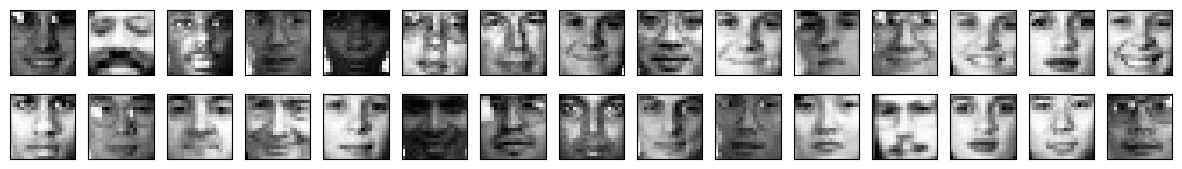

In [7]:

plot_faces(np.random.permutation(faces)[:30])


## Task 1: Distance function for a vector

complete the following function so that given a vector $v \in \mathbb{R}^n$ and a `numpy` array $X \in \mathbb{R}^{m\times n}$ (whose rows are vectors of the same size as $v$) returns a new array $\in \mathbb{R}^m$ with the Euclidean distance between $v$ and each vector in $X$.

Recall that the Euclidean distance between vectors $z=[z_0,...z_{n-1}]$ and $w=[w_0,...,w_{n-1}]$ is given by

$$\text{distance}(z,w) = \sqrt{\sum_{i=0}^{n-1} (z_i-w_i)^2}$$


**hint**: use [`np.linalg.norm`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) to compute a distance between two vectors

**challenge**: solve it using one line of code.

**note**: your function must return a 1D numpy array of dimension $m$, not a list.

for instance, for the following values of $v$ and $X$

    X = array([[9, 5, 1, 3, 8, 3, 3, 3, 9, 2],
               [9, 7, 0, 7, 9, 1, 4, 7, 3, 6],
               [8, 0, 0, 5, 0, 5, 5, 1, 1, 5],
               [8, 2, 9, 5, 6, 0, 8, 7, 2, 8],
               [0, 6, 3, 0, 6, 6, 1, 2, 8, 0]])
                  
    v = np.array([9, 7, 0, 7, 9, 1, 4, 7, 3, 6])


you should get the following result

    array([ 9.74679434,  0.        , 13.89244399, 11.91637529, 16.40121947])


In [8]:
def distances(v, X):
    result = np.linalg.norm(X - v, axis=1)
    return result

check manually your code

In [9]:
X = np.random.randint(10, size=(5,10))
v = X[1]

print ("X=\n", X)
print ("\nv=", v)
distances(v, X)

X=
 [[3 6 1 0 7 3 5 2 4 5]
 [1 1 0 9 1 8 0 8 3 0]
 [1 1 4 8 2 4 1 9 8 0]
 [2 0 0 7 8 1 2 1 1 9]
 [7 2 4 4 6 8 3 8 6 8]]

v= [1 1 0 9 1 8 0 8 3 0]


array([16.09347694,  0.        ,  7.81024968, 15.55634919, 13.60147051])

**submit your code**

In [10]:
student.submit_task(globals(), task_id="task_01");

## Task 2: Positions of closest vectors

complete the following function so that given $v$ and $X$ as previously, returns the positions of the $n$ closest vectors to $v$ in $X$.

**hint**: use the [`np.argsort`](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html) function

**challenge**: solve it using one line of code

for the example $v$ and $X$ above you should get the following outputs

    >> closest(v, X, 2)
    array([1, 0])

    >> closest(v, X, 3)
    array([1, 0, 3])


In [11]:
def closest(v, X, n):
    assert n<len(X), "n must at most the number of vectors in X"
    result = np.argsort(np.linalg.norm(X - v, axis=1))[:n]
    return result

check manually your code

In [12]:
X = np.random.randint(10, size=(5,10))
v = X[1]

print ("X=\n", X)
print ("\nv=", v,"\n\n")
print (closest(v, X, 2))
print (closest(v, X, 3))

X=
 [[6 1 1 3 3 0 5 6 9 5]
 [3 1 4 5 5 8 3 8 9 8]
 [3 3 1 2 7 7 6 6 6 9]
 [9 7 3 2 9 4 6 5 4 6]
 [5 8 7 6 4 4 5 3 6 9]]

v= [3 1 4 5 5 8 3 8 9 8] 


[1 2]
[1 2 0]


### observe now how we can use your functions to search for faces similar to any other face

TARGET FACE


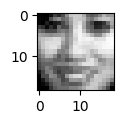

In [13]:

plt.figure(figsize=(1,1))
fi = 314 # np.random.randint(len(faces)) # 314
face = faces[fi]
plt.imshow(faces[fi].reshape(19,19), cmap=plt.cm.Greys_r)
print ("TARGET FACE")


SIMILAR FACES


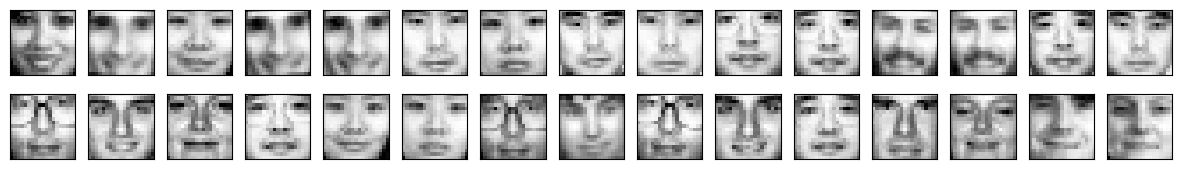

In [14]:

plot_faces(faces[closest(face, faces, 30)])
print ("SIMILAR FACES")


But they do not look so similar, this is because we are doing comparison **pixel by pixel**. We will fix this in the next task

**submit your code**

In [15]:
student.submit_task(globals(), task_id="task_02");

## Task 3: Use NMF to find similar faces

Make the comparison in the faces space resulting from transforming them using NMF. For this you have to:

- create an instance of NMF with `n_components=30, init="random", random_state=0`
- fit the instance with $X$
- transform $X$
- transform $v$
- return the positions of closest $n$ vectors in the transformed $X$ to the transformed $v$

For the target face above, you should get the following

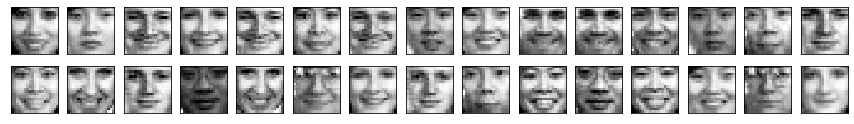

In [16]:

from IPython.display import Image
Image(filename='local/imgs/similar-images2.png')


In [17]:
def find_similar(v,X,n):
    from sklearn.decomposition import NMF

    nmf = NMF(n_components=30, init="random", random_state=0)
    nmf.fit(X) ## your code here. call the 'fit' method
    Xt = nmf.transform(X) # use nmf to transform X
    vt = nmf.transform(v.reshape(1, -1)) # use nmf to transform v .. you will have to use reshape like this v.reshape(1,-1)

    result = np.argsort(np.linalg.norm(Xt - vt, axis=1))[:n]

    return result

check manually your answer

/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


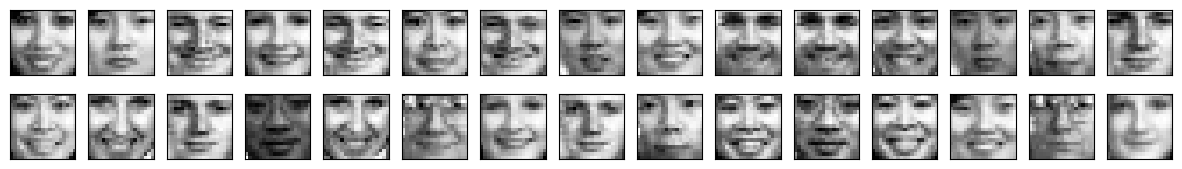

In [18]:

plot_faces(faces[find_similar(face, faces, 30)])


**submit your code**

In [19]:
student.submit_task(globals(), task_id="task_03");